# Hormone Receptor and Demographic EDA — Han

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

%matplotlib inline

receptors = ["Estrogen Status", "Progesterone Status"]

In [2]:
# Support opening the notebook from either the project root or notebooks folder.
data_path = Path("data/seer_breast_cancer_cleaned.csv")
if not data_path.exists():
    data_path = Path("../data/seer_breast_cancer_cleaned.csv")
df = pd.read_csv(data_path)
df.head()

,Age,Race,Marital Status,T Stage,N Stage,6th Stage,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Regional Node Positive,Survival Months,Status
0,43,"Other (American Indian/AK Native, Asian/Pacifi...",Married (including common law),T2,N3,IIIC,Moderately differentiated; Grade II,Regional,40,Positive,Positive,19,11,1,Alive
1,47,"Other (American Indian/AK Native, Asian/Pacifi...",Married (including common law),T2,N2,IIIA,Moderately differentiated; Grade II,Regional,45,Positive,Positive,25,9,2,Alive
2,67,White,Married (including common law),T2,N1,IIB,Poorly differentiated; Grade III,Regional,25,Positive,Positive,4,1,2,Dead
3,46,White,Divorced,T1,N1,IIA,Moderately differentiated; Grade II,Regional,19,Positive,Positive,26,1,2,Dead
4,63,White,Married (including common law),T2,N2,IIIA,Moderately differentiated; Grade II,Regional,35,Positive,Positive,21,5,3,Dead


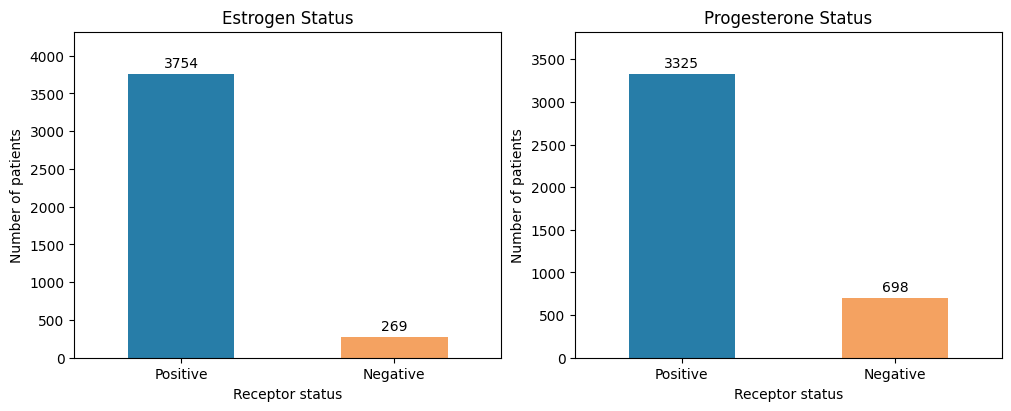

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), layout="constrained")
for ax, receptor in zip(axes, receptors):
    counts = df[receptor].value_counts().reindex(["Positive", "Negative"], fill_value=0)
    counts.plot.bar(ax=ax, color=["#277da8", "#f4a261"], rot=0)
    ax.set(title=receptor, xlabel="Receptor status", ylabel="Number of patients")
    ax.bar_label(ax.containers[0], padding=3)
    ax.set_ylim(0, counts.max() * 1.15)
plt.show()

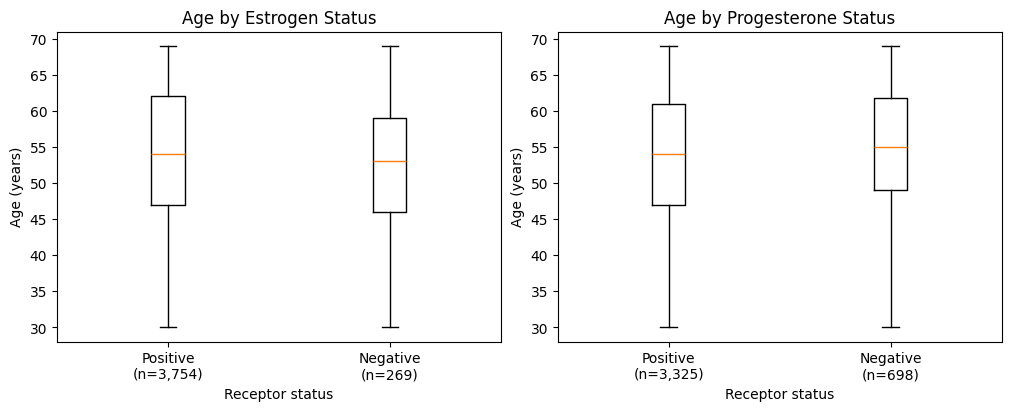

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), layout="constrained")
for ax, receptor in zip(axes, receptors):
    labels = ["Positive", "Negative"]
    ages = [df.loc[df[receptor] == label, "Age"].dropna() for label in labels]
    ax.boxplot(ages, tick_labels=[f"{label}\n(n={len(age):,})" for label, age in zip(labels, ages)])
    ax.set(title=f"Age by {receptor}", xlabel="Receptor status", ylabel="Age (years)")
plt.show()

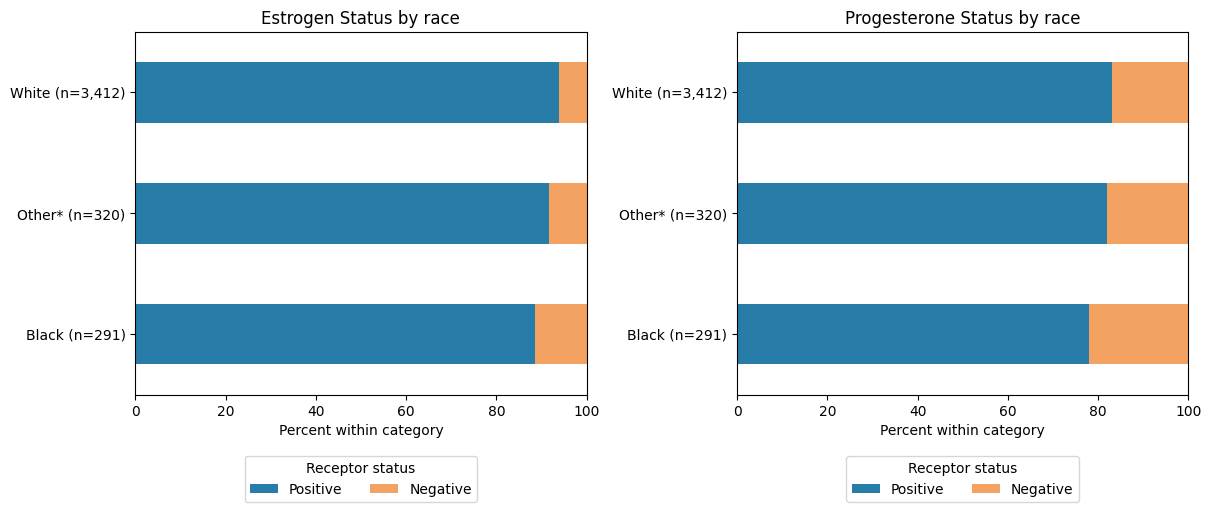

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), layout="constrained")
for ax, receptor in zip(axes, receptors):
    counts = pd.crosstab(df['Race'], df[receptor]).reindex(columns=["Positive", "Negative"], fill_value=0)
    percentages = counts.div(counts.sum(axis=1), axis=0) * 100
    percentages.index = [str(category).replace("Other (American Indian/AK Native, Asian/Pacific Islander)", "Other*").replace("Married (including common law)", "Married").replace("Single (never married)", "Single") + f" (n={n:,})" for category, n in counts.sum(axis=1).items()]
    percentages.plot.barh(stacked=True, ax=ax, color=["#277da8", "#f4a261"])
    ax.set(title=f"{receptor} by race", xlabel="Percent within category", ylabel="", xlim=(0, 100))
    ax.legend(title="Receptor status", loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2)
plt.show()

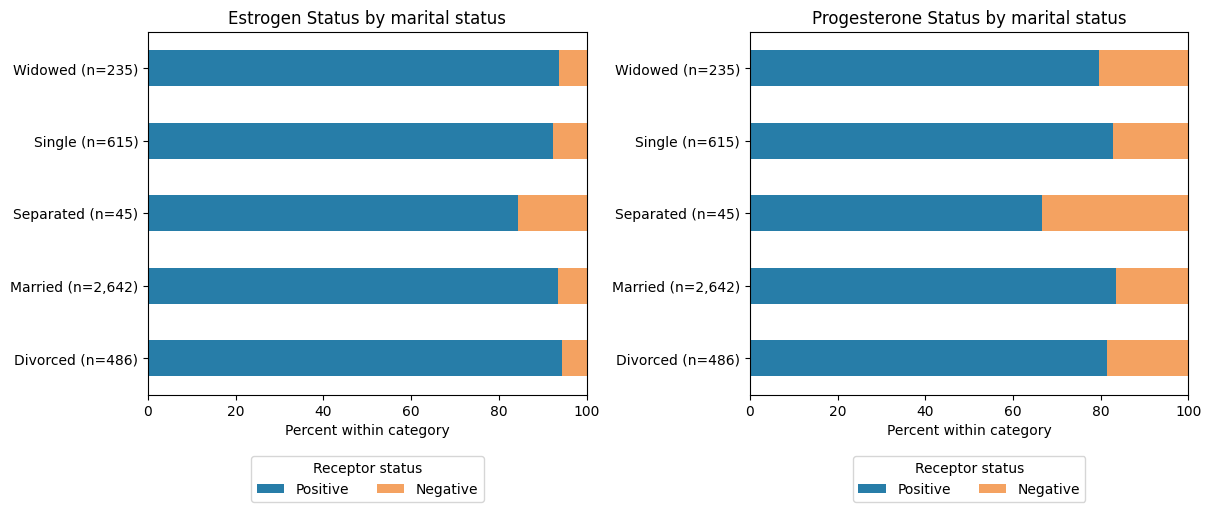

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), layout="constrained")
for ax, receptor in zip(axes, receptors):
    counts = pd.crosstab(df['Marital Status'], df[receptor]).reindex(columns=["Positive", "Negative"], fill_value=0)
    percentages = counts.div(counts.sum(axis=1), axis=0) * 100
    percentages.index = [str(category).replace("Other (American Indian/AK Native, Asian/Pacific Islander)", "Other*").replace("Married (including common law)", "Married").replace("Single (never married)", "Single") + f" (n={n:,})" for category, n in counts.sum(axis=1).items()]
    percentages.plot.barh(stacked=True, ax=ax, color=["#277da8", "#f4a261"])
    ax.set(title=f"{receptor} by marital status", xlabel="Percent within category", ylabel="", xlim=(0, 100))
    ax.legend(title="Receptor status", loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2)
plt.show()